SWASTHIKA M 24BAD121
   user_id  anime_id  rating
0        1        20      -1
1        1        24      -1
2        1        79      -1
3        1       226      -1
4        1       241      -1
Index(['user_id', 'anime_id', 'rating'], dtype='object')

Top 5 Similar Users:
 user_id
1776    0.864923
9825    0.715656
9775    0.621059
4364    0.596550
809     0.584472
Name: 1, dtype: float64

Top Recommended Anime:

                      name                                              genre  \
141      Nanatsu no Taizai  Action, Adventure, Ecchi, Fantasy, Shounen, Su...   
159           Angel Beats!        Action, Comedy, Drama, School, Supernatural   
288             Fairy Tail  Action, Adventure, Comedy, Fantasy, Magic, Sho...   
1036  High School DxD BorN  Action, Comedy, Demons, Ecchi, Harem, Romance,...   
2132   Sword Art Online II          Action, Adventure, Fantasy, Game, Romance   

      rating  
141     8.42  
159     8.39  
288     8.22  
1036    7.71  
2132    7.35  

RMSE:

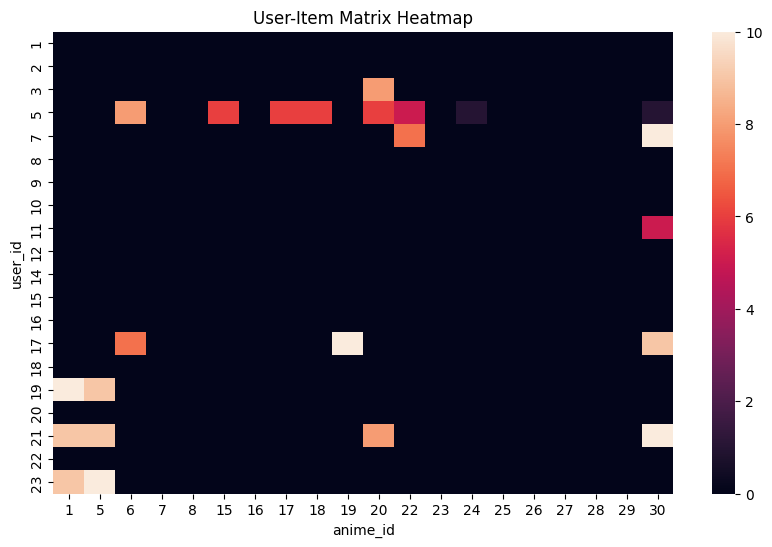

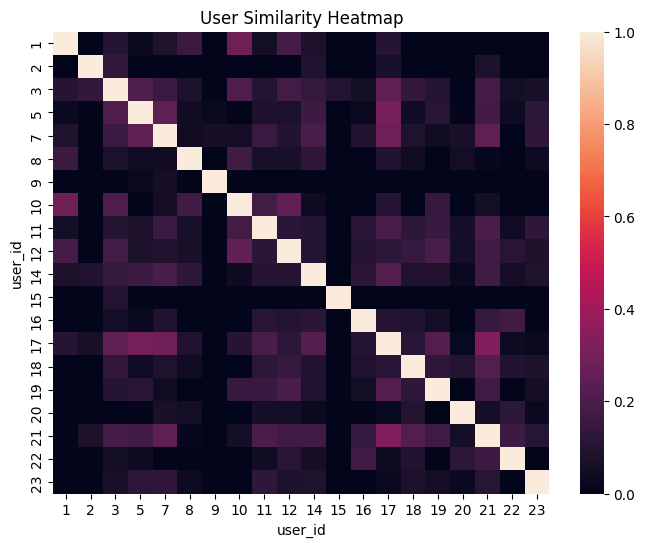

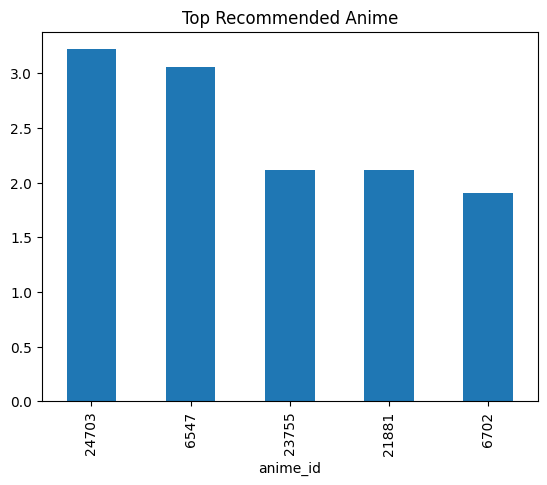

In [2]:
#scenario 1
print("SWASTHIKA M 24BAD121")
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


ratings = pd.read_csv("rating.csv")
anime = pd.read_csv("anime.csv")


print(ratings.head())
print(ratings.columns)

# Remove invalid ratings (-1)
ratings = ratings[ratings['rating'] != -1]

# Create User-Item Matrix
user_item_matrix = ratings.pivot_table(index='user_id', columns='anime_id', values='rating')


user_item_filled = user_item_matrix.fillna(0)

#Compute User Similarity
user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_filled.index,
                                 columns=user_item_filled.index)

# Select Target User
target_user = user_item_filled.index[0]

# Find Top 5 similar users
similar_users = user_similarity_df[target_user].sort_values(ascending=False)[1:6]
print("\nTop 5 Similar Users:\n", similar_users)

# Predict Ratings
def predict_ratings(user_id, user_item_matrix, similarity_df):
    sim_users = similarity_df[user_id].sort_values(ascending=False)[1:6]
    sim_scores = sim_users.values
    sim_users_ids = sim_users.index

    weighted_sum = np.dot(sim_scores, user_item_matrix.loc[sim_users_ids])
    sum_weights = np.sum(sim_scores)

    predicted = weighted_sum / sum_weights
    return pd.Series(predicted, index=user_item_matrix.columns)

predicted_ratings = predict_ratings(target_user, user_item_filled, user_similarity_df)

#  Recommend Top-N Anime
already_rated = user_item_matrix.loc[target_user].dropna().index

recommendations = predicted_ratings.drop(already_rated)
top_recommendations = recommendations.sort_values(ascending=False).head(5)

# Convert anime_id to names
top_anime = anime[anime['anime_id'].isin(top_recommendations.index)]

print("\nTop Recommended Anime:\n")
print(top_anime[['name', 'genre', 'rating']])

# Evaluation (RMSE & MAE)
actual = user_item_matrix.loc[target_user].dropna()
predicted = predicted_ratings[actual.index]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nRMSE:", rmse)
print("MAE:", mae)

# Visualization

# User-Item Matrix Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()

# Similarity Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Heatmap")
plt.show()

# Top Recommendations Plot
top_recommendations.plot(kind='bar')
plt.title("Top Recommended Anime")
plt.show()

SWASTHIKA M 24BAD121

Top 5 Similar Anime IDs:
 anime_id
5      0.629231
205    0.560847
30     0.534405
6      0.530208
227    0.529499
Name: 1, dtype: float64

Top Similar Anime:

                                name  \
104                 Samurai Champloo   
152  Cowboy Bebop: Tengoku no Tobira   
211          Neon Genesis Evangelion   
214                           Trigun   
456                             FLCL   

                                                 genre  rating  
104  Action, Adventure, Comedy, Historical, Samurai...    8.50  
152              Action, Drama, Mystery, Sci-Fi, Space    8.40  
211  Action, Dementia, Drama, Mecha, Psychological,...    8.32  
214                             Action, Comedy, Sci-Fi    8.32  
456    Action, Comedy, Dementia, Mecha, Parody, Sci-Fi    8.06  

Recommended Anime for User:

                      name                                              genre  \
159           Angel Beats!        Action, Comedy, Drama, School, Supernatura

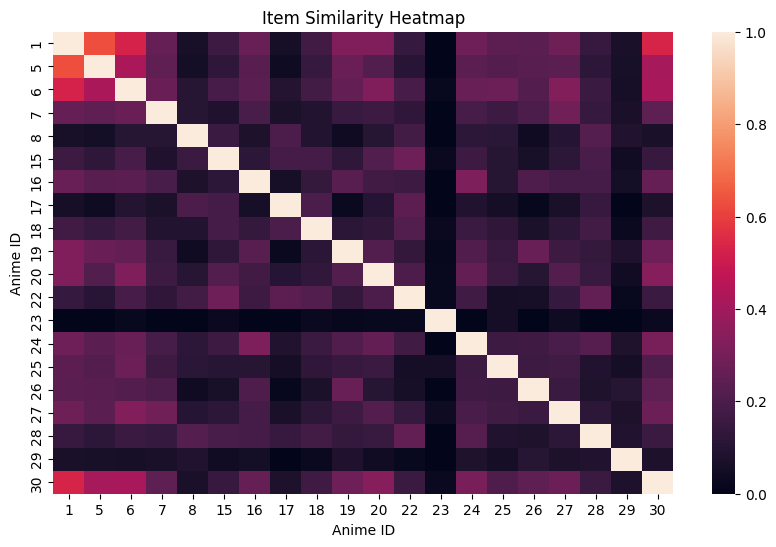

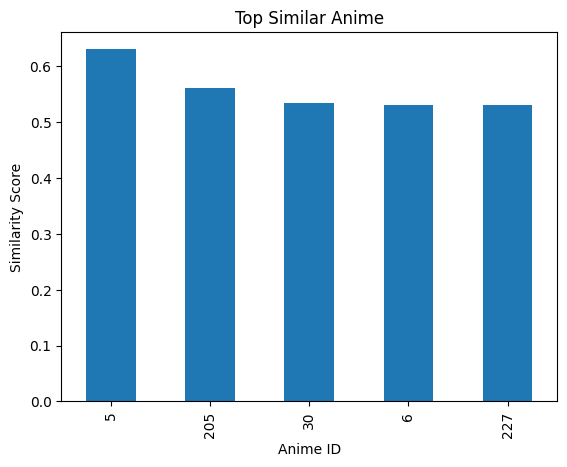

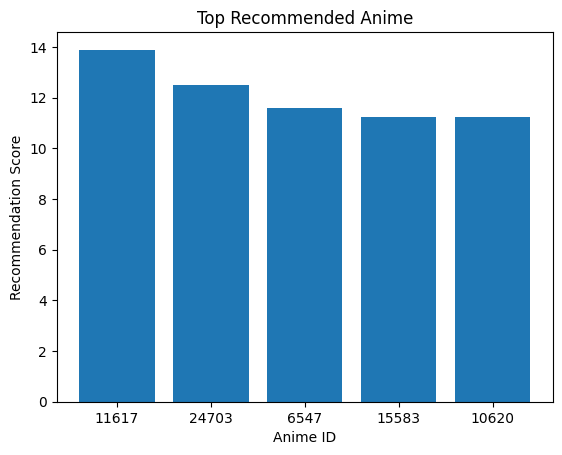

In [5]:
#scenario 2
print("SWASTHIKA M 24BAD121")
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

#  Load Dataset
ratings = pd.read_csv("rating.csv")
anime = pd.read_csv("anime.csv")

#  Preprocessing
ratings = ratings[ratings['rating'] != -1]

#  Create Item-User Matrix
item_user_matrix = ratings.pivot_table(index='anime_id', columns='user_id', values='rating')

#  Handle Missing Values
item_user_filled = item_user_matrix.fillna(0)

#  Compute Item Similarity
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_filled.index,
                                 columns=item_user_filled.index)

#  Select Target Item
target_item = item_user_filled.index[0]

# Top 5 similar items
similar_items = item_similarity_df[target_item].sort_values(ascending=False)[1:6]

print("\nTop 5 Similar Anime IDs:\n", similar_items)

# Convert to names
similar_anime = anime[anime['anime_id'].isin(similar_items.index)]

print("\nTop Similar Anime:\n")
print(similar_anime[['name', 'genre', 'rating']])

#  Recommend Items for a User
target_user = ratings['user_id'].iloc[0]

user_ratings = ratings[ratings['user_id'] == target_user]

scores = {}

for _, row in user_ratings.iterrows():
    item = row['anime_id']
    rating = row['rating']

    similar = item_similarity_df[item].sort_values(ascending=False)[1:6]

    for sim_item, sim_score in similar.items():
        if sim_item not in scores:
            scores[sim_item] = 0
        scores[sim_item] += sim_score * rating

# Sort recommendations
recommended_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]

recommended_ids = [i[0] for i in recommended_items]

recommended_anime = anime[anime['anime_id'].isin(recommended_ids)]

print("\nRecommended Anime for User:\n")
print(recommended_anime[['name', 'genre', 'rating']])

#  Evaluation (RMSE)
actual = user_ratings['rating']
predicted = [scores.get(i, 0) for i in user_ratings['anime_id']]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE:", rmse)

#  VISUALIZATION

# Item Similarity Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.xlabel("Anime ID")
plt.ylabel("Anime ID")
plt.show()

#  Top Similar Items Bar Chart
similar_items.plot(kind='bar')

plt.title("Top Similar Anime")
plt.xlabel("Anime ID")
plt.ylabel("Similarity Score")

plt.show()

# Recommended Items Bar Chart
rec_df = pd.DataFrame(recommended_items, columns=['anime_id', 'score'])

plt.figure()
plt.bar(rec_df['anime_id'].astype(str), rec_df['score'])

plt.title("Top Recommended Anime")
plt.xlabel("Anime ID")
plt.ylabel("Recommendation Score")

plt.show()